# 1. Cargar bibliotecas y csv

In [83]:
import os
import requests
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import missingno as msno
from sklearn.model_selection import train_test_split

In [84]:
df = pd.read_csv("/workspaces/steven10015-intro-ml/data/raw/medical_insurance_cost.csv")
# Fijar el id como indice
pd.set_option('display.max_columns', None)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [85]:
df.shape

(1338, 7)

# 2. Cribado manual

In [86]:
unicos = df.nunique()
df[unicos[unicos==1].index]

""
0
1
2
3
4
...
1333
1334
1335
1336


In [87]:
dup_fil=df.duplicated().sum()
print("No hay filas duplicadas" if dup_fil==0 else "Hay filas duplicadas")


Hay filas duplicadas


In [88]:
df.drop_duplicates(inplace=True)

In [89]:
dup_col=df.T.duplicated(keep=False).sum()
print("No hay variables exactamente iguales" if dup_col==0 else "Hay variables exactamente iguales")

No hay variables exactamente iguales


In [90]:
df.shape

(1337, 7)

In [91]:
missing=df.isna().mean()*100
missing

age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64

In [92]:
total_filas_con_na = df.isna().any(axis=1).sum()
print(f"Total de filas con al menos un dato faltante: {total_filas_con_na}")

Total de filas con al menos un dato faltante: 0


<Axes: >

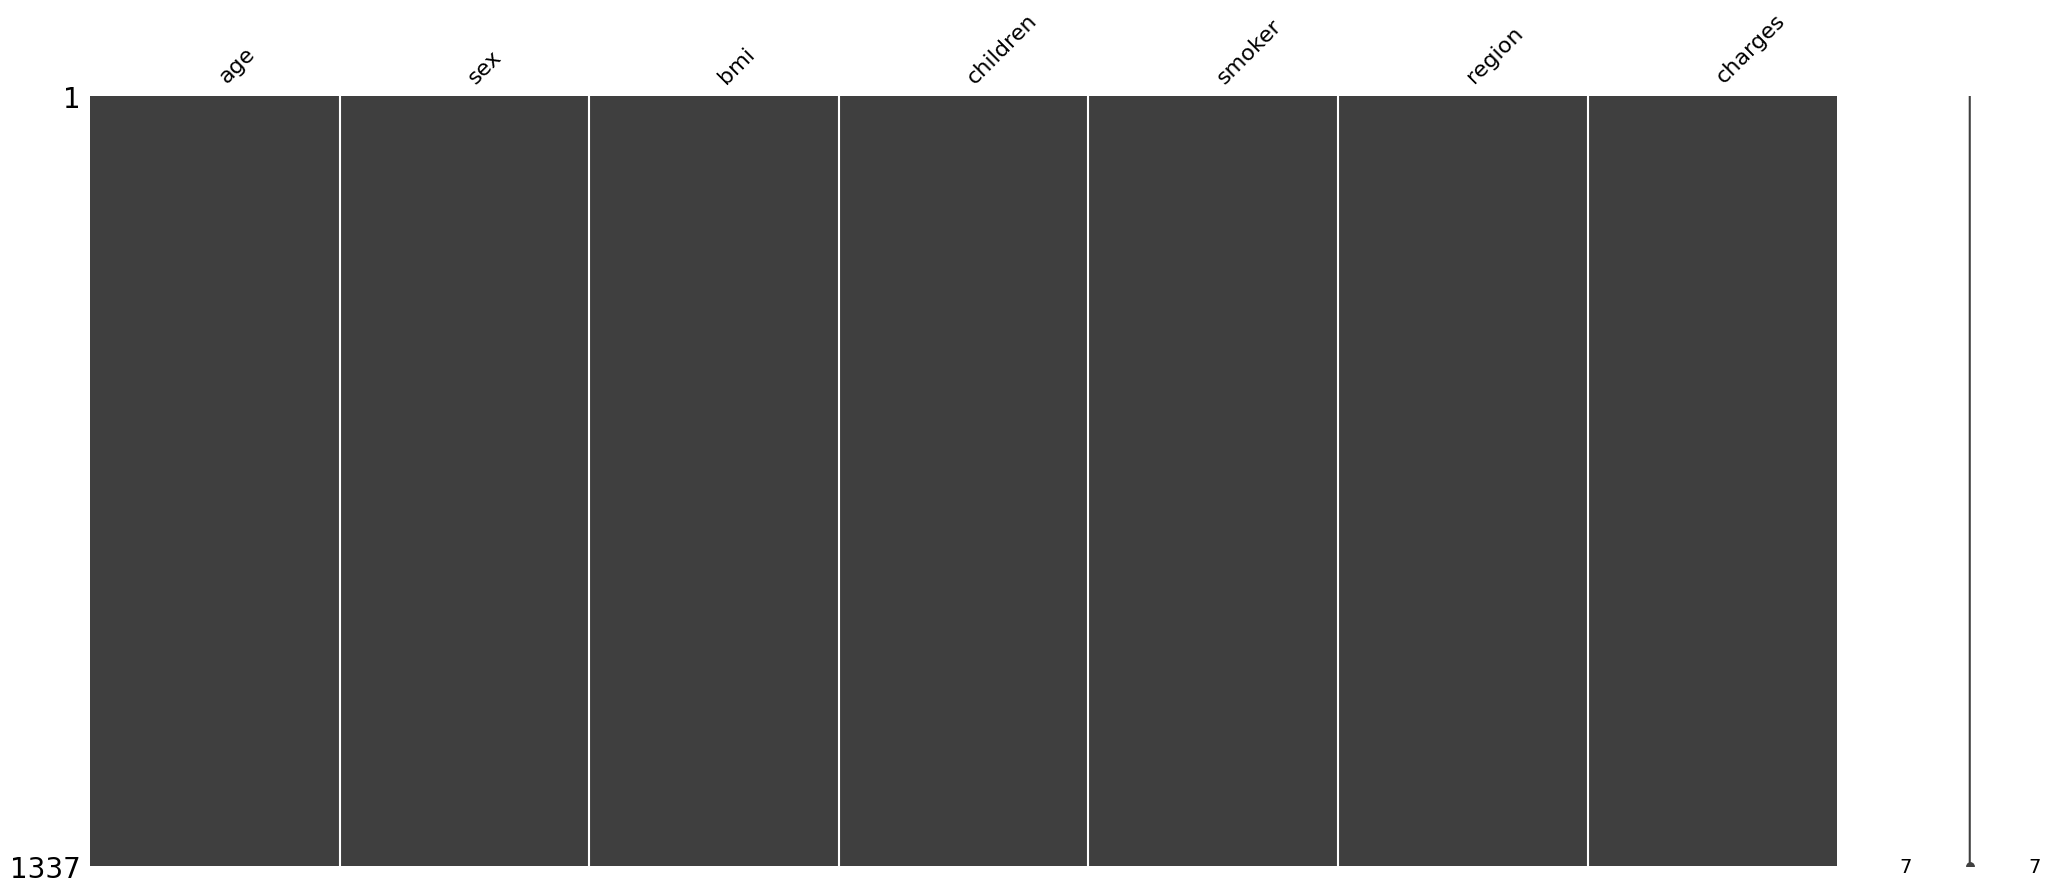

In [93]:
msno.matrix(df)

In [94]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [95]:
df = pd.get_dummies(df, columns=['sex'])
columnas_sexo_codificadas = [col for col in df.columns if col.startswith('Sexo_')] 
df[columnas_sexo_codificadas] = df[columnas_sexo_codificadas].astype(int)

In [96]:
df.head()

,age,bmi,children,smoker,region,charges,sex_female,sex_male
0,19,27.900,0,yes,southwest,16884.92400,True,False
1,18,33.770,1,no,southeast,1725.55230,False,True
2,28,33.000,3,no,southeast,4449.46200,False,True
3,33,22.705,0,no,northwest,21984.47061,False,True
4,32,28.880,0,no,northwest,3866.85520,False,True
